In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import mode

In [2]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [14]:
import locomp
from locomp import *
from locomp.MLmodels import *
from locomp.util_locomp import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

import functions_case as il
import importlib

In [17]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

# Separate features and target
X = df.drop(columns=['phase', 'Metadata_well'])
y = df['Metadata_well'].astype(str)

feature_names = X.columns.tolist()
feature_pairs = list(itertools.combinations(range(X.shape[1]), 2))
X = X.to_numpy()
y = y.to_numpy()

# Split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949, stratify=y)

In [12]:
np.unique(y)

array(['0', '1', '10', '100', '1000'], dtype=object)

In [6]:
def DecisionTreeClass(X,Y):
    fit = DecisionTreeClassifier(max_depth = 50, 
                                 max_features=10,
                                 random_state=949
                                 ).fit(X,Y)
    return fit

In [5]:
J1 = 0
J2 = 1
m_ratio = 0.5
n_ratio = 0.5
B = 5000
fit_func = DecisionTreeClass

In [7]:
predictions, in_mp_obs, in_mp_feature = predictMPClass(X, y, X, n_ratio, m_ratio, B, fit_func, n_jobs = -1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/Users/mariahloehr/IICD/IICD/feature_importance/locomp/util_locomp.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  idx_I =Y_pd.groupby(0, group_keys=False).apply(lambda x: x.sample(frac=n_ratio))
/Users/mariahloehr/IICD/IICD/feature_importance/locomp/util_locomp.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  idx_I =Y_pd.groupby(0, 

In [ ]:
# 0.2 Step 1: convert one-hot predictions to class indices
class_preds = predictions.argmax(axis=2)   # shape (B, N)

# Step 2: majority vote per sample
majority_vote = mode(class_preds, axis=0, keepdims=False).mode  # shape (N,)

# Define the mapping from class index → treatment label
class_labels = np.array([0, 1, 10, 100, 1000])

# Convert indices to labels
mode_pred = class_labels[majority_vote]

acc = accuracy_score(y_test, mode_pred)

print(f"Minipatch model accuracy: {acc:.3f}")

Minipatch model accuracy: 0.637


In [8]:
# 0.5 Step 1: convert one-hot predictions to class indices
class_preds = predictions.argmax(axis=2)   # shape (B, N)

# Step 2: majority vote per sample
majority_vote = mode(class_preds, axis=0, keepdims=False).mode  # shape (N,)

# Define the mapping from class index → treatment label
class_labels = np.array([0, 1, 10, 100, 1000])

# Convert indices to labels
mode_pred = class_labels[majority_vote]

acc = accuracy_score(y_test, mode_pred)

print(f"Minipatch model accuracy: {acc:.3f}")

ValueError: Found input variables with inconsistent numbers of samples: [12901, 64502]

In [58]:
# === Load existing results DataFrame ===
results_df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_mp_results.csv", index_col=0)

# === Set values ===
model_name = "Tree MP"  # or whatever is appropriate
results_df.loc[model_name, 'Accuracy'] = acc

# === Save updated results ===
results_df.to_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_mp_results.csv")

In [ ]:
np.savez("ensemble_rf.npz", predictions=predictions, obs=in_mp_obs, feats=in_mp_feature)

LOCO

In [12]:
data = np.load("ensemble_rf.npz")

# Access arrays
predictions = data["predictions"]
in_mp_obs   = data["obs"]
in_mp_features  = data["feats"]

In [17]:
print("X.shape:", X_train.shape)
print("predictions.shape:", predictions.shape)

X.shape: (51601, 20)
predictions.shape: (5000, 12901, 5)


In [7]:
x=LOCOMPClass(X,y,n_ratio,m_ratio,B,fit_func, selected_features=[],alpha=0.1,bonf=True)
x.run_loco()
#x.loco_ci

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/Users/mariahloehr/IICD/IICD/feature_importance/locomp/util_locomp.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  idx_I =Y_pd.groupby(0, group_keys=False).apply(lambda x: x.sample(frac=n_ratio))
/Users/mariahloehr/IICD/IICD/feature_importance/locomp/util_locomp.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  idx_I =Y_pd.groupby(0, 

In [8]:
x.loco_ci

array([[ 1.00000000e+00,  0.00000000e+00, -8.07810603e-03,
        -7.76610803e-03, -7.92210703e-03],
       [ 1.00000000e+00,  0.00000000e+00, -6.96650771e-03,
        -6.70491053e-03, -6.83570912e-03],
       [ 1.00000000e+00,  5.15601703e-04, -9.56194190e-04,
        -1.90945396e-04, -5.73569793e-04],
       [ 1.00000000e+00,  0.00000000e+00, -3.47751617e-03,
        -2.87157164e-03, -3.17454391e-03],
       [ 1.00000000e+00,  0.00000000e+00, -3.17035884e-03,
        -2.50989783e-03, -2.84012833e-03],
       [ 0.00000000e+00,  0.00000000e+00,  3.38521679e-02,
         3.54487811e-02,  3.46504745e-02],
       [ 1.00000000e+00,  0.00000000e+00, -3.10165221e-03,
        -2.67654344e-03, -2.88909783e-03],
       [ 1.00000000e+00,  0.00000000e+00, -4.49025241e-03,
        -4.04894324e-03, -4.26959783e-03],
       [ 1.00000000e+00,  0.00000000e+00, -2.19334582e-03,
        -1.59138300e-03, -1.89236441e-03],
       [ 0.00000000e+00,  0.00000000e+00,  1.59763555e-03,
         2.41440483e-03

In [9]:
ci_df = pd.DataFrame(x.loco_ci)
ci_df = ci_df.rename(columns={2: 'lower_bound', 3: 'upper_bound', 4: 'score'})
ci_df['feature_name'] = feature_names
fig_df = ci_df.nlargest(10, "score")

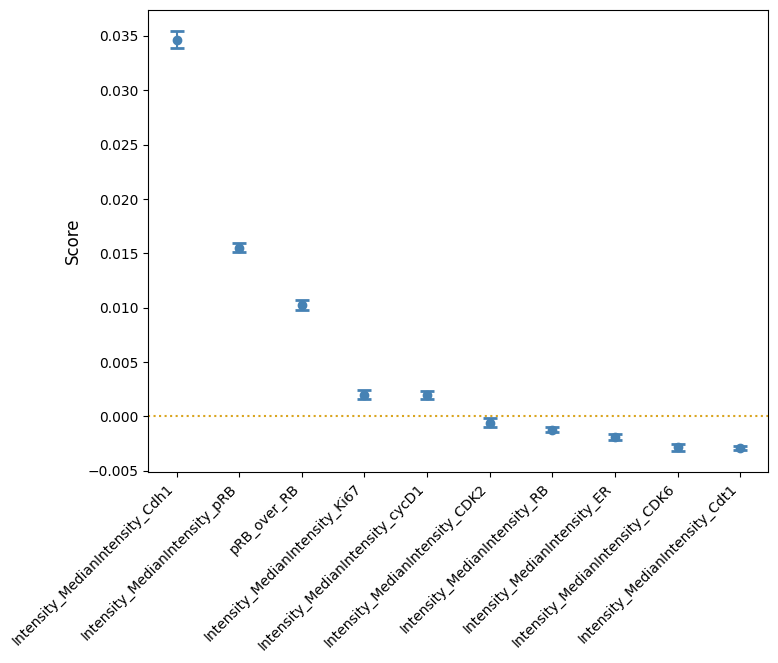

In [12]:
# Plot
plt.figure(figsize=(8, 6))
plt.errorbar(
    fig_df["feature_name"], fig_df["score"],
    yerr=[fig_df["score"] - fig_df["lower_bound"], fig_df["upper_bound"] - fig_df["score"]],
    fmt="o", capsize=5, capthick=2, markersize=6, color="steelblue"
)
plt.axhline(y=0, color='goldenrod', linestyle='dotted')
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha = 'right')
plt.show()

In [13]:
ci_df.to_csv('/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/rf_loco.csv', index=False)

iLOCO

In [15]:
def get_mp_metric(X, Y, n_ratio, m_ratio, B, model, feature_pairs):
    """
    Computes interaction metrics (iLOCO) for multiple feature pairs using an ensemble model.

    Parameters:
    X (numpy.ndarray): Feature matrix.
    Y (numpy.ndarray): Target variable.
    n_ratio (float): Ratio parameter for ensemble fitting.
    m_ratio (float): Ratio parameter for ensemble fitting.
    B (int): Number of bootstrap samples.
    model (object): Trained model for interaction computation.
    feature_pairs (list of tuples): List of tuples where each tuple contains two feature indices (j1, j2) for the feature pair.

    Returns:
    dict: Dictionary where keys are feature pairs (j1, j2) and values are dictionaries containing:
          - 'iloco': The mean interaction value.
          - 'iloco_max': The maximum interaction value, ensuring non-negative.
          - 'iloco_ratio': The ratio of iloco to the mean of r.
    """
    # Create and fit an ensemble model
    ensemble = il.Ensemble(model).fit(X, Y, n_ratio, m_ratio, B)

    # Compute feature interactions for the given list of feature pairs
    result = il.featureInteractions(X, Y, n_ratio, m_ratio, B, model, feature_pairs, bonferroni=True)

    return result

In [20]:
DecisionTreeClass = DecisionTreeClassifier(max_depth = 50, 
                                 max_features=10,
                                 random_state=949
                                 )

In [ ]:
mp_results = []
mp_ci = []
mp_results = get_mp_metric(X, y, n_ratio, m_ratio, B, model = DecisionTreeClass, feature_pairs=feature_pairs)
mp_scores = [mp_results[(j, k)]['iloco'] for (j, k) in feature_pairs]
mp_ci = [mp_results[(j, k)]["ci"] for (j, k) in feature_pairs]

# Generate all pairwise combinations
pairwise_names = list(itertools.combinations(feature_names, 2))
# Convert each tuple to a single string
pairwise_names_str = [' & '.join(pair) for pair in pairwise_names]
data = {'feature': pairwise_names_str, 'scores': mp_scores, 'ci': mp_ci }
df = pd.DataFrame(data)

df.to_csv("cancer_iloco_decisionTree.csv", index=False)